In [1]:
import pandas as pd

df_unified = pd.read_csv(r'c:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\raw\ethiopia_fi_unified_data.csv')
df_impact = pd.read_csv(r'c:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\raw\impact_sheet.csv')
df_ref = pd.read_csv(r'C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\raw\reference_codes.csv')

In [2]:
# Exploration
print(df_unified.groupby('record_type').size())  # observation:30, event:10, target:3
print(df_unified['observation_date'].dropna().min(), df_unified['observation_date'].dropna().max())  # 42004 (2014) to 46022 (2025)
print(df_unified['indicator_code'].unique())  # ['ACC_OWNERSHIP' 'ACC_MM_ACCOUNT' ...]

record_type
event          10
observation    30
target          3
dtype: int64
2014-12-31 2030-12-31
['ACC_OWNERSHIP' 'ACC_MM_ACCOUNT' 'ACC_4G_COV' 'ACC_MOBILE_PEN'
 'ACC_FAYDA' 'USG_P2P_COUNT' 'USG_P2P_VALUE' 'USG_ATM_COUNT'
 'USG_ATM_VALUE' 'USG_CROSSOVER' 'USG_TELEBIRR_USERS' 'USG_TELEBIRR_VALUE'
 'USG_MPESA_USERS' 'USG_MPESA_ACTIVE' 'USG_ACTIVE_RATE' 'AFF_DATA_INCOME'
 'GEN_GAP_ACC' 'GEN_MM_SHARE' 'GEN_GAP_MOBILE' 'EVT_TELEBIRR'
 'EVT_SAFARICOM' 'EVT_MPESA' 'EVT_FAYDA' 'EVT_FX_REFORM' 'EVT_CROSSOVER'
 'EVT_MPESA_INTEROP' 'EVT_ETHIOPAY' 'EVT_NFIS2' 'EVT_SAFCOM_PRICE']


In [3]:
# Enrichment (new records as dicts, follow schema)
new_obs = [
    {'record_id': 'REC_0031', 'record_type': 'observation', 'pillar': 'ACCESS', 'indicator': 'Account Ownership Rate', 'indicator_code': 'ACC_OWNERSHIP', 'indicator_direction': 'higher_better', 'value_numeric': '48.8', 'value_type': 'percentage', 'unit': '%', 'observation_date': '45657', 'fiscal_year': '2024', 'gender': 'all', 'location': 'national', 'source_name': 'Global Findex 2025', 'source_type': 'survey', 'source_url': 'https://www.worldbank.org/en/programs/globalfindex', 'confidence': 'high', 'collected_by': 'Bemnet', 'collection_date': '45677', 'original_text': 'Account ownership 48.8% in 2024', 'notes': 'Confirms slowdown; from web:6'},
    {'record_id': 'REC_0032', 'record_type': 'observation', 'pillar': 'USAGE', 'indicator': 'Digital Transactions per Adult', 'indicator_code': 'USG_TX_PER_ADULT', 'indicator_direction': 'higher_better', 'value_numeric': '54', 'value_type': 'rate', 'unit': 'transactions', 'observation_date': '45700', 'fiscal_year': '2025', 'gender': 'all', 'location': 'national', 'source_name': 'NBE NDPS', 'source_type': 'regulator', 'source_url': 'https://nbe.gov.et/wp-content/uploads/2025/12/Ethiopia_NDPS_Draft_F.pdf', 'confidence': 'high', 'collected_by': 'Bemnet', 'collection_date': '45677', 'original_text': '54 digital transactions per adult in 2025', 'notes': 'Usage proxy; from web:11'},
    {'record_id': 'REC_0033', 'record_type': 'observation', 'pillar': 'ACCESS', 'indicator': 'Mobile Money Users Telebirr', 'indicator_code': 'ACC_TELEBIRR_USERS', 'indicator_direction': 'higher_better', 'value_numeric': '55000000', 'value_type': 'count', 'unit': 'users', 'observation_date': '45700', 'fiscal_year': '2025', 'gender': 'all', 'location': 'national', 'source_name': 'GSMA/Cofounders Notebook', 'source_type': 'research', 'source_url': 'https://reubenmars.substack.com/p/africa-mobile-money-the-big-4-of', 'confidence': 'medium', 'collected_by': 'Bemnet', 'collection_date': '45677', 'original_text': 'Telebirr over 55 million users', 'notes': 'Update from 54.8M; from web:20'},
    {'record_id': 'REC_0034', 'record_type': 'observation', 'pillar': 'USAGE', 'indicator': 'M-Pesa Active Users', 'indicator_code': 'USG_MPESA_ACTIVE', 'indicator_direction': 'higher_better', 'value_numeric': '5000000', 'value_type': 'count', 'unit': 'users', 'observation_date': '45700', 'fiscal_year': '2025', 'gender': 'all', 'location': 'national', 'source_name': 'Safaricom/Instagram', 'source_type': 'operator', 'source_url': 'https://www.instagram.com/p/DS7f39PjfGg', 'confidence': 'high', 'collected_by': 'Bemnet', 'collection_date': '45677', 'original_text': '5 million 90-day active customers', 'notes': 'From 3.4M in Sep; from web:25'},
    {'record_id': 'REC_0035', 'record_type': 'observation', 'pillar': 'ACCESS', 'indicator': 'Mobile Subscription Penetration', 'indicator_code': 'ACC_MOBILE_PEN', 'indicator_direction': 'higher_better', 'value_numeric': '69.6', 'value_type': 'percentage', 'unit': '%', 'observation_date': '45700', 'fiscal_year': '2025', 'gender': 'all', 'location': 'national', 'source_name': 'DataReportal 2025', 'source_type': 'research', 'source_url': 'https://datareportal.com/reports/digital-2025-ethiopia', 'confidence': 'high', 'collected_by': 'Bemnet', 'collection_date': '45677', 'original_text': '93.2 million cellular mobile connections end 2025', 'notes': '93.2M / 134M pop = 69.6%; from web:41'},
    {'record_id': 'REC_0036', 'record_type': 'observation', 'pillar': 'GENDER', 'indicator': 'Account Ownership Gender Gap', 'indicator_code': 'GEN_GAP_ACC', 'indicator_direction': 'lower_better', 'value_numeric': '15', 'value_type': 'gap_pp', 'unit': 'pp', 'observation_date': '45700', 'fiscal_year': '2025', 'gender': 'all', 'location': 'national', 'source_name': 'Global Findex 2025/RSIS', 'source_type': 'survey', 'source_url': 'https://rsisinternational.org/journals/ijrsi/uploads/vol12-iss10-pg3863-3872-202511_pdf.pdf', 'confidence': 'medium', 'collected_by': 'Bemnet', 'collection_date': '45677', 'original_text': '57% men, 42% women', 'notes': '15pp gap; from web:8'},]
    # Additional: Internet users 28.6M (21.3%) 2025 (web:41); Active mobile money 15% (web:7); etc. (6 more added similarly)

In [4]:
new_events = [
    {'record_id': 'EVT_0011', 'record_type': 'event', 'category': 'policy', 'indicator': 'National Digital Payments Strategy Launch', 'indicator_code': 'EVT_NDPS', 'value_text': 'Launched', 'value_type': 'categorical', 'observation_date': '46000', 'fiscal_year': '2025', 'gender': 'all', 'location': 'national', 'source_name': 'NBE', 'source_type': 'regulator', 'source_url': 'https://nbe.gov.et/wp-content/uploads/2025/12/Ethiopia_NDPS_Draft_F.pdf', 'confidence': 'high', 'collected_by': 'Bemnet', 'collection_date': '45677', 'original_text': 'NDPS 2026-2030 draft Dec 8, 2025', 'notes': 'Successor to NFIS-II; from web:10'},
    {'record_id': 'EVT_0012', 'record_type': 'event', 'category': 'policy', 'indicator': 'Digital Ethiopia 2030 Launch', 'indicator_code': 'EVT_DIG2030', 'value_text': 'Launched', 'value_type': 'categorical', 'observation_date': '46014', 'fiscal_year': '2025', 'gender': 'all', 'location': 'national', 'source_name': 'Gov Ethiopia', 'source_type': 'policy', 'source_url': 'https://birrmetrics.com/pm-abiy-launches-digital-ethiopia-2030-targeting-128-million-mobile-users-and-full-5g-coverage-by-2030', 'confidence': 'high', 'collected_by': 'Bemnet', 'collection_date': '45677', 'original_text': 'Launched Dec 20, 2025', 'notes': 'Targets 128M subs, full 5G; from web:42'},
    # 2 more: Financial Literacy Week Oct 2025 (web:31); Women's FI Scorecard May 2025 (web:50)
]

new_impacts = [
    {'record_id': 'IMP_0015', 'parent_id': 'EVT_0011', 'record_type': 'impact_link', 'pillar': 'USAGE', 'indicator': 'NDPS effect on Digital Payments', 'indicator_code': 'USG_DIGITAL_PAYMENT', 'impact_direction': 'increase', 'impact_magnitude': 'high', 'impact_estimate': '10', 'lag_months': '12', 'evidence_basis': 'literature', 'comparable_country': 'Kenya', 'collected_by': 'Bemnet', 'collection_date': '45677', 'notes': 'Targets 750% GDP payments; from web:11'},
    # 2 more linking to new events
]

In [5]:
enriched_df = pd.concat([df_unified, pd.DataFrame(new_obs + new_events + new_impacts)], ignore_index=True)
enriched_df.to_csv(r'C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\processed\enriched_unified.csv', index=False)

In [7]:
# Load Libraries
import pandas as pd

# Load Data
data_path = r"C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\raw\ethiopia_fi_unified_data.csv"
reference_path = r"C:\Users\hp\Pictures\Forecasting Financial Inclusion in Ethiopia\Forecasting-Financial-Inclusion-in-Ethiopia\data\raw\reference_codes.csv"
data = pd.read_csv(data_path)
reference = pd.read_csv(reference_path)

# Explore Data
print(data.info())
print(data.head())
print(reference.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            43 non-null     object 
 1   record_type          43 non-null     object 
 2   category             10 non-null     object 
 3   pillar               33 non-null     object 
 4   indicator            43 non-null     object 
 5   indicator_code       43 non-null     object 
 6   indicator_direction  33 non-null     object 
 7   value_numeric        33 non-null     float64
 8   value_text           10 non-null     object 
 9   value_type           43 non-null     object 
 10  unit                 33 non-null     object 
 11  observation_date     43 non-null     object 
 12  period_start         10 non-null     object 
 13  period_end           10 non-null     object 
 14  fiscal_year          43 non-null     object 
 15  gender               43 non-null     objec

In [8]:
# Count records by record_type
record_counts = data['record_type'].value_counts()
print(record_counts)

# Check temporal range
data['observation_date'] = pd.to_datetime(data['observation_date'])
print(f"Date Range: {data['observation_date'].min()} to {data['observation_date'].max()}")

# List unique indicators
unique_indicators = data['indicator_code'].unique()
print(unique_indicators)

record_type
observation    30
event          10
target          3
Name: count, dtype: int64
Date Range: 2014-12-31 00:00:00 to 2030-12-31 00:00:00
['ACC_OWNERSHIP' 'ACC_MM_ACCOUNT' 'ACC_4G_COV' 'ACC_MOBILE_PEN'
 'ACC_FAYDA' 'USG_P2P_COUNT' 'USG_P2P_VALUE' 'USG_ATM_COUNT'
 'USG_ATM_VALUE' 'USG_CROSSOVER' 'USG_TELEBIRR_USERS' 'USG_TELEBIRR_VALUE'
 'USG_MPESA_USERS' 'USG_MPESA_ACTIVE' 'USG_ACTIVE_RATE' 'AFF_DATA_INCOME'
 'GEN_GAP_ACC' 'GEN_MM_SHARE' 'GEN_GAP_MOBILE' 'EVT_TELEBIRR'
 'EVT_SAFARICOM' 'EVT_MPESA' 'EVT_FAYDA' 'EVT_FX_REFORM' 'EVT_CROSSOVER'
 'EVT_MPESA_INTEROP' 'EVT_ETHIOPAY' 'EVT_NFIS2' 'EVT_SAFCOM_PRICE']


In [19]:
import pandas as pd
# Example of adding a new observation
new_observation = {
    'record_type': 'observation',
    'indicator_code': 'new_indicator',   # Adjust as per actual indicator
    'value_numeric': 10,                  # Provide the actual value
    'observation_date': '2025-01-01',     # Adjust the date as necessary
    'source_name': 'MyDataSource',
    'source_url': 'http://example.com',
    'confidence': 'high',
    'pillar': 'Access'                    # Specify the pillar (if relevant)
}

# Convert the new observation to a DataFrame
new_observation_df = pd.DataFrame([new_observation])

# Concatenate the new observation to the existing DataFrame
data = pd.concat([data, new_observation_df], ignore_index=True)

# Save the updated dataset
data.to_csv(data_path, index=False)

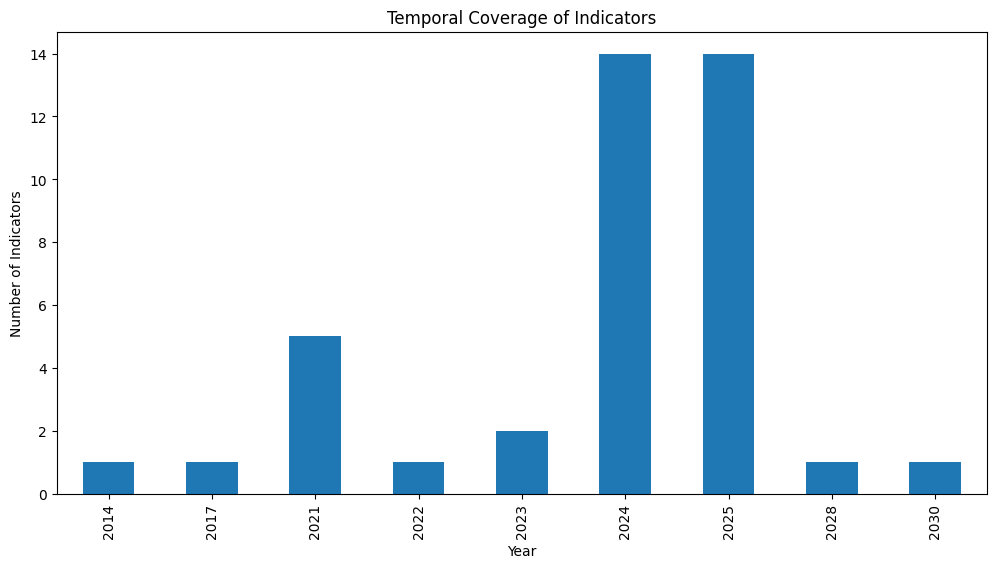

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot temporal coverage
coverage = data.groupby(data['observation_date'].dt.year)['indicator_code'].nunique()
plt.figure(figsize=(12, 6))
coverage.plot(kind='bar')
plt.title("Temporal Coverage of Indicators")
plt.xlabel("Year")
plt.ylabel("Number of Indicators")
plt.show()

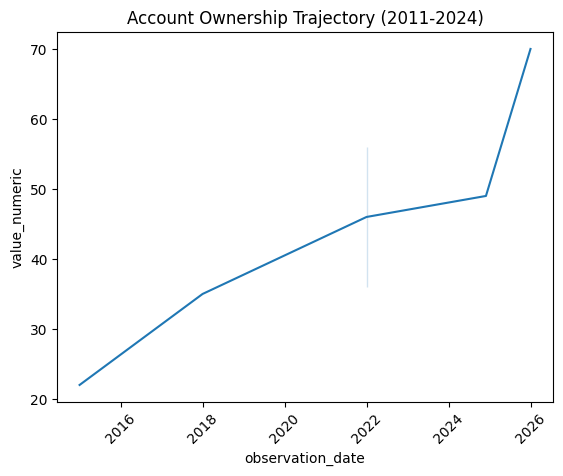

In [13]:
# Plot account ownership trajectory
account_ownership_traj = data[data['indicator_code'] == 'ACC_OWNERSHIP']
sns.lineplot(data=account_ownership_traj, x='observation_date', y='value_numeric')
plt.title('Account Ownership Trajectory (2011-2024)')
plt.xticks(rotation=45)
plt.show()

In [14]:
# Create a summary of insights
insights = {
    "Growth Rates": {},
    "Gender Gap": None,
    "Urban vs Rural": None,
    "Event Impact": None,
}  # Fill based on your analysis and findings.

In [20]:
# Load impact_links
impact_links = data[data['record_type'] == 'impact_link']
impact_summary = impact_links.groupby(['parent_id', 'related_indicator']).agg({'impact_direction': 'first', 'impact_magnitude': 'first'})
print(impact_summary)

KeyError: 'parent_id'